In [6]:
import pandas as pd
import requests
from IPython.display import YouTubeVideo

## Working with APIs
#### Example 1: Using request and the open-meteo API for weather predictions
https://open-meteo.com/en/docs

In [53]:
import requests

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 34.4208,
    "longitude": -119.6982,
    "start_date": "2025-10-01",
    "end_date": "2025-11-13",
    "time_zone": "auto",
    "hourly": ["temperature_2m", "relative_humidity_2m", "pressure_msl", "cloud_cover", 
               "wind_speed_10m", "wind_speed_180m", "wind_direction_10m", "wind_direction_180m", 
               "precipitation", "visibility", "soil_temperature_0cm", "soil_moisture_0_to_1cm", "is_day"]
}

response = requests.get(url, params=params)
data = response.json()


In [54]:
data

{'latitude': 34.40734,
 'longitude': -119.70551,
 'generationtime_ms': 100.68655014038086,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 14.0,
 'hourly_units': {'time': 'iso8601',
  'temperature_2m': '°C',
  'relative_humidity_2m': '%',
  'pressure_msl': 'hPa',
  'cloud_cover': '%',
  'wind_speed_10m': 'km/h',
  'wind_speed_180m': 'km/h',
  'wind_direction_10m': '°',
  'wind_direction_180m': '°',
  'precipitation': 'mm',
  'visibility': 'm',
  'soil_temperature_0cm': '°C',
  'soil_moisture_0_to_1cm': 'm³/m³',
  'is_day': ''},
 'hourly': {'time': ['2025-10-01T00:00',
   '2025-10-01T01:00',
   '2025-10-01T02:00',
   '2025-10-01T03:00',
   '2025-10-01T04:00',
   '2025-10-01T05:00',
   '2025-10-01T06:00',
   '2025-10-01T07:00',
   '2025-10-01T08:00',
   '2025-10-01T09:00',
   '2025-10-01T10:00',
   '2025-10-01T11:00',
   '2025-10-01T12:00',
   '2025-10-01T13:00',
   '2025-10-01T14:00',
   '2025-10-01T15:00',
   '2025-10-01T16:00',
   '2025-10-

In [8]:
myData = pd.DataFrame(data)
myData

,latitude,longitude,generationtime_ms,utc_offset_seconds,timezone,timezone_abbreviation,elevation,hourly_units,hourly
time,37.763283,-122.41286,56.83136,0,GMT,GMT,18.0,iso8601,"[2025-10-01T00:00, 2025-10-01T01:00, 2025-10-0..."
temperature_2m,37.763283,-122.41286,56.83136,0,GMT,GMT,18.0,°C,"[20.8, 19.6, 17.3, 17.8, 17.7, 17.8, 17.5, 17...."
relative_humidity_2m,37.763283,-122.41286,56.83136,0,GMT,GMT,18.0,%,"[71, 71, 85, 74, 81, 81, 85, 82, 76, 76, 74, 7..."
pressure_msl,37.763283,-122.41286,56.83136,0,GMT,GMT,18.0,hPa,"[1015.5, 1015.4, 1015.5, 1015.6, 1015.7, 1015...."
cloud_cover,37.763283,-122.41286,56.83136,0,GMT,GMT,18.0,%,"[12, 38, 5, 36, 90, 92, 97, 99, 89, 46, 100, 3..."
wind_speed_10m,37.763283,-122.41286,56.83136,0,GMT,GMT,18.0,km/h,"[17.2, 12.5, 11.9, 11.1, 6.0, 9.0, 9.0, 5.4, 3..."
wind_speed_180m,37.763283,-122.41286,56.83136,0,GMT,GMT,18.0,km/h,"[18.7, 17.6, 16.5, 18.0, 15.5, 15.7, 17.4, 16...."
wind_direction_10m,37.763283,-122.41286,56.83136,0,GMT,GMT,18.0,°,"[250, 237, 245, 257, 237, 217, 217, 222, 252, ..."
wind_direction_180m,37.763283,-122.41286,56.83136,0,GMT,GMT,18.0,°,"[218, 211, 212, 213, 216, 212, 210, 204, 198, ..."
precipitation,37.763283,-122.41286,56.83136,0,GMT,GMT,18.0,mm,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [9]:
len(myData["hourly"]["temperature_2m"])

1056

In [10]:
myData.index.tolist()

['time',
 'temperature_2m',
 'relative_humidity_2m',
 'pressure_msl',
 'cloud_cover',
 'wind_speed_10m',
 'wind_speed_180m',
 'wind_direction_10m',
 'wind_direction_180m',
 'precipitation',
 'visibility',
 'soil_temperature_0cm',
 'soil_moisture_0_to_1cm',
 'is_day']

In [11]:
myTable = pd.DataFrame()
for name in myData.index.tolist():
    myTable[name] = myData["hourly"][name]

                      

In [12]:
myTable

,time,temperature_2m,relative_humidity_2m,pressure_msl,cloud_cover,wind_speed_10m,wind_speed_180m,wind_direction_10m,wind_direction_180m,precipitation,visibility,soil_temperature_0cm,soil_moisture_0_to_1cm,is_day
0,2025-10-01T00:00,20.8,71,1015.5,12,17.2,18.7,250,218,0.0,20700.0,18.7,0.108,1
1,2025-10-01T01:00,19.6,71,1015.4,38,12.5,17.6,237,211,0.0,21500.0,17.6,0.109,1
2,2025-10-01T02:00,17.3,85,1015.5,5,11.9,16.5,245,212,0.0,15600.0,17.1,0.109,0
3,2025-10-01T03:00,17.8,74,1015.6,36,11.1,18.0,257,213,0.0,19900.0,17.0,0.111,0
4,2025-10-01T04:00,17.7,81,1015.7,90,6.0,15.5,237,216,0.0,17400.0,16.9,0.111,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1051,2025-11-13T19:00,15.3,95,1010.8,100,10.6,42.1,235,198,0.2,5700.0,15.4,0.346,1
1052,2025-11-13T20:00,15.0,92,1010.2,100,5.4,36.4,222,201,1.8,9100.0,15.5,0.333,1
1053,2025-11-13T21:00,14.9,91,1010.3,100,7.0,32.0,235,206,0.7,13800.0,15.4,0.327,1
1054,2025-11-13T22:00,14.6,92,1009.7,100,4.1,29.0,195,212,0.4,13800.0,15.2,0.322,1


<Axes: xlabel='temperature_2m', ylabel='soil_temperature_0cm'>

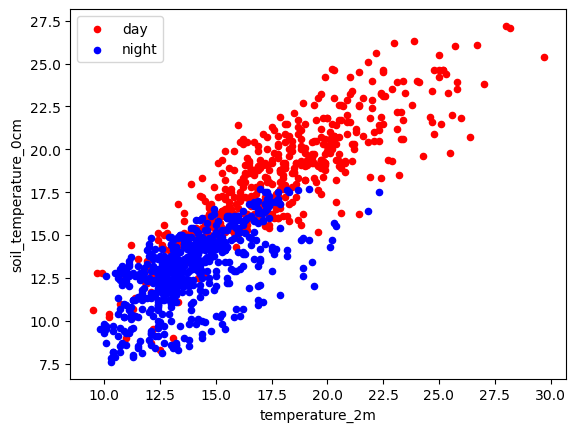

In [73]:
import matplotlib.pyplot as plt

#plt.scatter(myTable['temperature_2m'], myTable['soil_temperature_0cm'])

fig, ax = plt.subplots(1, 1)
subset = myTable[myTable['is_day'] == 1]
subset.plot.scatter(x='temperature_2m', y='soil_temperature_0cm',  color='red', label='day', ax = ax)
subset2 = myTable[myTable['is_day'] == 0]
subset2.plot.scatter(x='temperature_2m', y='soil_temperature_0cm',  color='blue', label='night', ax = ax)

In [13]:
myTable.to_csv('output.csv', index=False) 

#### Example 2: Using request and the SpaceX API
API info and documentation: https://github.com/r-spacex/SpaceX-API/blob/master/docs/README.md

Note that this API does not seem to have most recent data (the date below shows 2022)


In [4]:
import requests

response = requests.get("https://api.spacexdata.com/v4/launches/latest")
data = response.json()

print("Mission Name:", data["name"])
print("Date:", data["date_utc"])
print("Success:", data["success"])
print("Rocket ID:", data["rocket"])
print("Details:", data["details"])

Mission Name: Crew-5
Date: 2022-10-05T16:00:00.000Z
Success: True
Rocket ID: 5e9d0d95eda69973a809d1ec
Details: None


In [3]:
import requests

#response_spaceX = requests.get("https://api.spacexdata.com/v4/launchpads")
response_spaceX = requests.get("https://api.spacexdata.com/v4/launches")
data_spaceX= response_spaceX.json()




In [15]:
spaceX_data = pd.DataFrame(data_spaceX)

In [16]:
spaceX_data.keys()

Index(['fairings', 'links', 'static_fire_date_utc', 'static_fire_date_unix',
       'net', 'window', 'rocket', 'success', 'failures', 'details', 'crew',
       'ships', 'capsules', 'payloads', 'launchpad', 'flight_number', 'name',
       'date_utc', 'date_unix', 'date_local', 'date_precision', 'upcoming',
       'cores', 'auto_update', 'tbd', 'launch_library_id', 'id'],
      dtype='object')

In [33]:
youTube_ID = spaceX_data['links'][0]['youtube_id']

youTube_ID

'0a_00nJ_Y88'

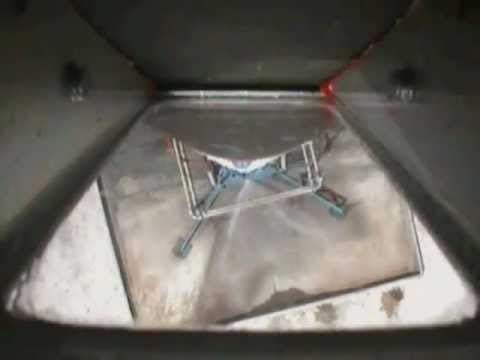

In [34]:
from IPython.display import YouTubeVideo
YouTubeVideo(str(youTube_ID))

#### Example 3: Using request and the OMDb API (Open Movie Database)
API info and documentation: http://www.omdbapi.com/
Here we need an API key

In [52]:
import requests

#url = "http://www.omdbapi.com/"
url = "http://www.omdbapi.com/?i=tt3896198&apikey=198270c"
params = {
    "t": "Avatar",
    #"apikey": "198270c"

}

response_ombd = requests.get(url, params=params)
data_ombd = response_ombd.json()

data_ombd

{'Title': 'Avatar',
 'Year': '2009',
 'Rated': 'PG-13',
 'Released': '18 Dec 2009',
 'Runtime': '162 min',
 'Genre': 'Action, Adventure, Fantasy',
 'Director': 'James Cameron',
 'Writer': 'James Cameron',
 'Actors': 'Sam Worthington, Zoe Saldaña, Sigourney Weaver',
 'Plot': 'A paraplegic Marine dispatched to the moon Pandora on a unique mission becomes torn between following his orders and protecting the world he feels is his home.',
 'Language': 'English, Spanish',
 'Country': 'United States, United Kingdom',
 'Awards': 'Won 3 Oscars. 91 wins & 131 nominations total',
 'Poster': 'https://m.media-amazon.com/images/M/MV5BMDEzMmQwZjctZWU2My00MWNlLWE0NjItMDJlYTRlNGJiZjcyXkEyXkFqcGc@._V1_SX300.jpg',
 'Ratings': [{'Source': 'Internet Movie Database', 'Value': '7.9/10'},
  {'Source': 'Rotten Tomatoes', 'Value': '81%'},
  {'Source': 'Metacritic', 'Value': '83/100'}],
 'Metascore': '83',
 'imdbRating': '7.9',
 'imdbVotes': '1,448,400',
 'imdbID': 'tt0499549',
 'Type': 'movie',
 'DVD': 'N/A',
 

In [40]:
print("Title:", data_ombd ["Title"])
print("Year:", data_ombd ["Year"])
print("Director:", data_ombd ["Director"])
print("IMDB Rating:", data_ombd ["imdbRating"])

Title: Inception
Year: 2010
Director: Christopher Nolan
IMDB Rating: 8.8
